# Testar Randomized Search com KNN

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
import sys
from math import ceil

from difflib import SequenceMatcher
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Load Created Functions
from functions import *

# Set random seed for reproducibility
np.random.seed(40111)

<a class="anchor" id="4">

# **4. Import Datasets**

[Back to TOP](#TOP)
</a>

Here, we are importing with pd.read_csv() the files to start our project and converting them into Pandas DataFrames. CarID was set to index since it's the unique identifier in all data sets.

In [3]:
train = pd.read_csv('../../data/train.csv')
test = pd.read_csv('../../data/test.csv')

<a class="anchor" id="4">

## **4.1** Define new index

[Back to TOP](#TOP)
</a>

For all partitions we will assign the "carID" column as the index, as it represents the number identifier for each individual car.

In [4]:
train.set_index('carID', inplace = True)
test.set_index('carID', inplace = True)

<a class="anchor" id="5">

# **5. Data Cleaning**

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_1">

## **5.1** Types Correction
[Back to TOP](#TOP)
</a>

In the EDA phase we noticed some inconsistencies in the features types. We will decide what to do with these errors and correct them.

Before starting, we will create a copy of the original dataframes to avoid any unwanted changes to the original data.

In [5]:
train = train.copy()
test = test.copy()

We are going to decide how to correct the data and this decision will be based on the percentage of incorrect values.

We will analyse the train dataset and take action in both train and test datasets.

We had previously identified that there are float values in the columns `Year`, `hasDamage` and `previousOwners` that should be integers as they represent discrete variables and a boolean in the case of hasDamage.

<a class="anchor" id="5_1_1">

### **5.1.1** Year and previousOwners columns correction
[Back to TOP](#TOP)
</a>

In [6]:
# percentage of float values in year and previousOwners columns
num_incorrect_year = (train['year'] % 1 != 0).sum() / train.shape[0] * 100
print(f'Percentage of incorrect values in year column: {num_incorrect_year:.2f}%')

num_incorrect_previousOwners = (train['previousOwners'] % 1 != 0).sum() / train.shape[0] * 100
print(f'Percentage of incorrect values in previousOwners column: {num_incorrect_previousOwners:.2f}%')


Percentage of incorrect values in year column: 2.91%
Percentage of incorrect values in previousOwners column: 3.01%


We decided to round all values of the features because the percentage of incorrect values is close to 3% (minimal). We chose rounding over flooring or ceiling because rounding gives the value that is mathematically closest to the original number, therefore minimizing bias and error.

In [7]:
#Rounds numeric values: values with decimal part >= 0.5 go up, others go down.
for col in ['year', 'previousOwners']:
    train[col] = np.floor(train[col] + 0.5).astype('Int64')
    test[col] = np.floor(test[col] + 0.5).astype('Int64')

<a class="anchor" id="5_1_2">

### **5.1.2** hasDamage Column Correction
[Back to TOP](#TOP)
</a>

In the HasDamage column, we only have 0's and NaN values. We decided to fill the NaN's with 1's to create boolean features by assuming that NaN values mean that there is damage to the car. Our rationale was that the customer prefers to ommit when there is damage to the car to raise its value. 

We agreed that this change was urgent and, because of that, it was done before the splitting.

In [8]:
train['hasDamage']=train['hasDamage'].astype('Int64')
test['hasDamage']=test['hasDamage'].astype('Int64')

train['hasDamage']=train['hasDamage'].fillna(1)
test['hasDamage']=test['hasDamage'].fillna(1)

<a class="anchor" id="5_2">

## **5.2** Categorical Features correction

[Back to TOP](#TOP)

We had identified earlier that the categorical features present a lot of misspellings. We will address that here.

<a class="anchor" id="5_2_1">

### **5.2.1** Creating the Correction Function

[Back to TOP](#TOP)

We start by creating a function that corrects these strange values by using the library difflib.

In [9]:
# Function to calculate similarity between two strings
def similar(a, b):
    """
    Checks similarity between two strings using SequenceMatcher.
    It calculates the percentage of equal characters between both inputs.
    """

    return SequenceMatcher(None, a, b).ratio()


# Function to clean categorical column using difflib
def clean_with_diff(
    df, column,
    threshold_short,
    threshold_long 
):
    """
    Groups similar values and replaces them by the most frequent (mode).
    threshold_short: similarity threshold when both strings have <= 5 chars
    threshold_long: similarity threshold otherwise
    """
    # Get unique values in the column
    values = df[column].dropna().unique()
    groups = []
    used = set()
    
    # Group similar values
    for v in values:
        if v in used:
            continue
        
        # Start a new group
        group = [v]
        used.add(v)
        
        # Compare with other values
        for other in values:
            if other in used:
                continue

            # Choose the thresholds based on length
            if len(v) <= 5 and len(other) <= 5:
                threshold = threshold_short
            else:
                threshold = threshold_long

            # Check similarity. If similar, add to group.
            if similar(v.lower(), other.lower()) >= threshold:
                group.append(other)
                used.add(other)

        # Append the group to the list of groups
        groups.append(group)
    
    # Create mapping for each group and replace values with mode
    mapping = {}
    for group in groups:
        moda = df[df[column].isin(group)][column].mode()[0]
        for item in group:
            mapping[item] = moda
    
    df[column] = df[column].map(mapping).fillna(df[column])
    
    return df


<a class="anchor" id="5_2_2">

### **5.2.2** Correct the values

[Back to TOP](#TOP)

Now we are able to correct the values by calling the function. We have tested the corrections with different thresholds for all variables and landed on these to get the best results. 

In [10]:
# Correct 'Brand' column
clean_with_diff(train, 'Brand', threshold_short=0.6, threshold_long=0.6)
clean_with_diff(test, 'Brand', threshold_short=0.5, threshold_long=0.6)

# Correct 'transmission' column
clean_with_diff(train, 'transmission', threshold_short=0.7, threshold_long=0.7)
clean_with_diff(test, 'transmission', threshold_short=0.7, threshold_long=0.7)

# Correct 'model' column
clean_with_diff(train, 'model', threshold_short=0.70, threshold_long=0.90)
clean_with_diff(test, 'model', threshold_short=0.70, threshold_long=0.90)

# Correct 'fuelType' column
clean_with_diff(train, 'fuelType', threshold_short=0.8, threshold_long=0.8)
clean_with_diff(test, 'fuelType', threshold_short=0.8, threshold_long=0.8)

# The output shows us a part of the dataframe after the values corrections

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,
89856,Hyundai,I10,2023,Automatic,30700.000000,Petrol,205.0,41.5,1.6,61.0,3,0
106581,VW,Tiguan,2017,Semi-Auto,-48190.655673,Petrol,150.0,38.2,2.0,60.0,2,0
80886,BMW,2 Series,2016,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2,0
100174,Opel,Grandland X,2019,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1,0
81376,BMW,1 Series,2019,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,Tiguan,2017,Manual,27575.000000,Petrol,145.0,46.3,1.4,94.0,1,0
81363,BMW,X2,2020,Automatic,1980.000000,Petrol,145.0,34.0,2.0,39.0,3,0
76833,Audi,Q5,2019,Semi-Auto,8297.000000,Diesel,145.0,38.2,2.0,88.0,4,0


<a class="anchor" id="5_2_3">

### **5.2.3** Check corrections

[Back to TOP](#TOP)

In [11]:
corrected_columns = ['Brand', 'transmission', 'model', 'fuelType']

for column in corrected_columns:
    unique_values_train = train[column].unique()
    unique_values_test = test[column].unique()
    print(f"Unique values on the column '{column}' (train): {unique_values_train}")
    print('')
    print(f"Unique values on the column '{column}' (test): {unique_values_test}")
    print('')
    print('-----------------------------------')
    print('')

Unique values on the column 'Brand' (train): ['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'Hyundai' nan]

Unique values on the column 'Brand' (test): ['Hyundai' 'VW' 'BMW' 'Opel' 'Ford' 'Mercedes' 'Skoda' 'Toyota' 'Audi' nan]

-----------------------------------

Unique values on the column 'transmission' (train): ['Semi-Auto' 'Manual' 'Automatic' nan 'unknown' 'Other']

Unique values on the column 'transmission' (test): ['Automatic' 'Semi-Auto' 'Manual' 'unknown' nan 'Other']

-----------------------------------

Unique values on the column 'model' (train): [' Golf' ' Yaris' ' Q2' ' Fiesta' ' 2 Series' ' 3 Series' ' A3' ' Octavia'
 ' Passat' ' Focus' ' Insignia' ' A Class' ' Q3' ' Fabia' ' Ka+'
 ' GLC Class' ' I10' ' C Class' ' Polo' ' E Class' ' Q5' ' Up' ' C-HR'
 ' Mokka X' ' Corsa' ' Astra' ' TT' ' 5 Series' ' Aygo' ' 4 Series' ' SLK'
 ' Viva' ' T-Roc' ' EcoSport' ' Tucson' nan ' X-CLASS' ' X2' ' Rapid'
 ' A1' ' Auris' ' Sharan' ' Adam' ' X3' ' A8' ' B-MAX' ' A4' ' 

**Important Note:** For most of the columns that were corrected, the function seems to have worked properly.
However, in the case of the 'model' column, the results were not as good as in the other columns. This is because the original data contained a high number of unique and incorrect values, some of which were very similar to each other, making it impossible to achieve a perfect correction.

Nevertheless, the vast majority of the data is now properly cleaned and corrected.

Also based on the previous unique values analysis, we decided to check the percentage of the 'Other' category in the 'transmission' column. If the proportion is not significant, we believe it would be reasonable to replace it with an 'Unknown' category, as this simplification could make the next steps of our analysis easier and more consistent.

In [12]:
(train[train['transmission'] == 'Other'].shape[0] / train.shape[0] * 100).__round__(4)

0.0066

The percentage is very small so we are going to replace the category as mentioned before.

In [13]:
#Replace 'Other' to 'Unkown'
train['transmission'] = train['transmission'].replace('Other', 'unknown')
test['transmission'] = test['transmission'].replace('Other', 'unknown')
print(train['transmission'].unique())
print(test['transmission'].unique())

['Semi-Auto' 'Manual' 'Automatic' nan 'unknown']
['Automatic' 'Semi-Auto' 'Manual' 'unknown' nan]


<a class="anchor" id="5_3">

## **5.3** Invalid Values

[Back to TOP](#TOP)

<a class="anchor" id="5_3_1">

### **5.3.1** Invalid Values Analysis

[Back to TOP](#TOP)

In [14]:
# Create a list with the names of metric and categorical columns
metric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']
cat_cols = ['Brand', 'model', 'transmission', 'fuelType', 'hasDamage']

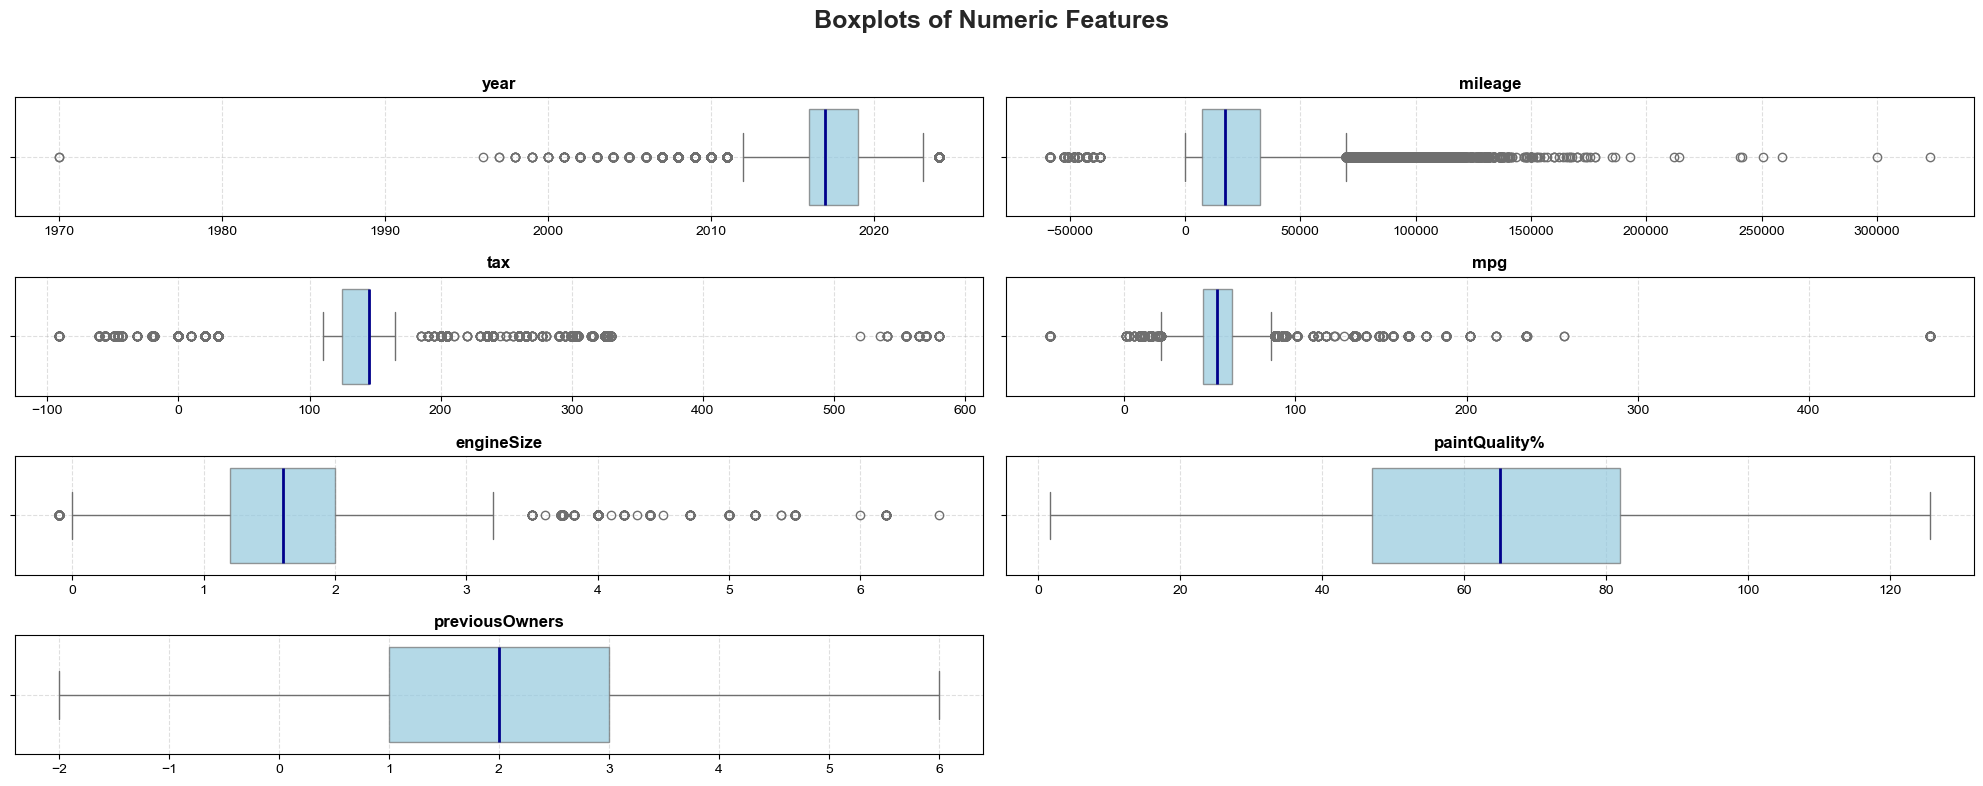

In [15]:
create_boxplots(train, metric_cols)

From the boxplots we found a lot of invalid values. Some features contain negative values (mileage, tax, mpg, engineSize, previousOwners), which are implausible and indicate data-entry errors and the paintQuality% column has values over 100%, which are invalid for a percentage.

Regarding the negative tax values, we thought they could represent to incentives on electric vehicles, so we will check if this checks out.

In [16]:
negtax_electric = train[(train['tax'] < 0) & (train['fuelType'] == 'Electric')]
print(f"Number of rows with negative 'tax' and 'Electric' fuel type: {len(negtax_electric)}")
negtax_electric[['tax', 'fuelType']].head(10)

Number of rows with negative 'tax' and 'Electric' fuel type: 0


,tax,fuelType
carID,,


From this analysis, we see that there are no electric vehicles with negative tax, so we eliminate that possibility.

<a class="anchor" id="5_3_2">

### **5.3.2** Invalid Values Treatment

[Back to TOP](#TOP)

From the conclusions done before and the analysis done in the Exploratory Data Analysis we know that the values with no sense (errors) are a small part of our data and that if we drop them we don't lose veracity.

After considering different approaches, we decided to replace the negative values with NaN since they do not make sense in the context of the features. This approach preserves data integrity and allows for consistent imputation later.
We will also cap the values exceeding 100% at 100%. This approach corrects the impossible values while preserving the rest of the data distribution. 

In [ ]:
# Create function to replace negative values with NaN
def replace_negatives_with_nan(df, metric_cols):
    """Replaces negative values in the specified metric columns with NaN."""

    for col in metric_cols:
        num_negatives = (df[col] < 0).sum()
        if num_negatives > 0:
            df.loc[df[col] < 0, col] = np.nan
    return df

# Replace negatives with NaN in both train and test datasets
train = replace_negatives_with_nan(train, metric_cols)
test = replace_negatives_with_nan(test, metric_cols)

In [ ]:
# Cap all values at 100%
train['paintQuality%'] = train['paintQuality%'].clip(upper=100)
test['paintQuality%'] = test['paintQuality%'].clip(upper=100)


Now the negative and wrong values are treated. 

**Important:** Before applying any outliers treatment we need to split the data into train and validation sets. This is important to avoid data leakage. After splitting the data we can apply the method using only the training set statistics.

<a class="anchor" id="6">

# **6 Data Partition**

[Back to TOP](#TOP)

Define the independent features as X and the dependent as Y

In [18]:
X = train.drop('price', axis = 1)
y = train['price']

In [20]:
train

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,Golf,2016,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4,0
53000,Toyota,Yaris,2019,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1,0
6366,Audi,Q2,2019,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4,0
29021,Ford,Fiesta,2018,12500,Manual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2,0
10062,BMW,2 Series,2019,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,C Class,2015,13498,Manual,14480.0,Petrol,125.0,53.300000,2.0,78.0,0,0
6265,Audi,Q3,2013,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2,0
54886,Toyota,Aygo,2017,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3,0


In [23]:
from random import randint
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor

# 1. Define your column groups
# Replace these with your actual list of column names
categorical_features = ['transmission', 'fuelType', 'Brand']
numerical_features = ['mileage', 'tax', 'mpg', 'engineSize', 'year']

# 2. Build the Numerical Pipeline
# Logic: Scale FIRST, then KNN Impute. 
# Why? KNN calculates distance. If you don't scale first, large numbers (Mileage) 
# will dominate small numbers (EngineSize) during imputation.
numeric_transformer = Pipeline(steps=[
    ('median_imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) 
])

# 3. Build the Categorical Pipeline
# Logic: Fill missing with Mode (Most Frequent) -> One Hot Encode
categorical_transformer = Pipeline(steps=[
    ('mode_imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4. Combine them into a Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 5. Create the Full Pipeline (Preprocessor + Model)
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor()) # You can swap this for RandomForestRegressor, etc.
])

# 6. Define the Parameter Grid for RandomizedSearch
param_grid = {
    "regressor__n_neighbors": [3, 5, 10, 30],              # 3..80
    "regressor__weights": ["uniform", "distance"],
    "regressor__p": [1, 2],                                # Manhattan vs Euclidiana
    "regressor__leaf_size": [10, 20, 30, 70, 80],
    "regressor__algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
}

# 7. Run RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=final_pipeline,
    param_distributions=param_grid,
    n_iter=10,             # Number of random combinations to try
    cv=5,                  # 5-Fold Cross-Validation
    scoring="r2",
    n_jobs=-1,             # Use all processors
    random_state=42,
    verbose=1
)

# Fit on your training data
random_search.fit(X, y)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'regressor__weights': 'distance', 'regressor__p': 1, 'regressor__n_neighbors': 10, 'regressor__leaf_size': 20, 'regressor__algorithm': 'auto'}
Best Score: 0.9087001423621732


In [27]:
from sklearn.metrics import accuracy_score

y_pred = random_search.predict(X_val)
acc_val = accuracy_score(y_val, y_pred)

print("CV Score:", random_search.best_score_)
print("Validation Score:", acc_val)

NameError: name 'X_val' is not defined